In [ ]:
# ---------------------------------------------------
# 0.0 IMPORTS & DATA UPLOAD
# ---------------------------------------------------
from google.colab import files
import pandas as pd
import io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif


# Load dataset
uploaded = files.upload()

for filename in uploaded.keys():
    df = pd.read_csv(filename)
    break

Saving BankChurners.csv to BankChurners.csv


In [ ]:
# ---------------------------------------------------
# 1.0 DATA OVERVIEW
# ---------------------------------------------------

# Drop last few columns that are irrelevant (based on the uploader statement on Kaggle)
df = df.iloc[:, :-2]

# Initial Data Overview
print("DataFrame Shape:", df.shape)
print("\nFirst 5 rows:\n", df.head())
print("\nLast 5 rows:\n", df.tail())
print("\nData Types and Missing Values:\n")
df.info()

print("Statistical summary of features:")
print(df.describe())

DataFrame Shape: (10127, 21)

First 5 rows:
    CLIENTNUM     Attrition_Flag  Customer_Age Gender  Dependent_count  \
0  768805383  Existing Customer            45      M                3   
1  818770008  Existing Customer            49      F                5   
2  713982108  Existing Customer            51      M                3   
3  769911858  Existing Customer            40      F                4   
4  709106358  Existing Customer            40      M                3   

  Education_Level Marital_Status Income_Category Card_Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
3     High School        Unknown  Less than $40K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   

   Months_on_book  ...  Months_Inactive_12_mon  Contacts_Count_12_mon  \
0              39  ...                       1

From the dataset overview, we can see that there are 6 categorical features. To get more accurate results when applying machine learning algorithms to this dataset, we need to encode these features into separate categories and map them to numeric values.

Based on the initial data overview, features like 'Education' and 'Attrition_Flag' have only two categories, making it easy to map them as 1 and 0. However, other categorical features like 'Education_Level' and 'Income_Category' have more than two categories.

We will check further to confirm the total count of categories for each feature.

In [ ]:
print(df.describe(include='object'))

           Attrition_Flag Gender Education_Level Marital_Status  \
count               10127  10127           10127          10127   
unique                  2      2               7              4   
top     Existing Customer      F        Graduate        Married   
freq                 8500   5358            3128           4687   

       Income_Category Card_Category  
count            10127         10127  
unique               6             4  
top     Less than $40K          Blue  
freq              3561          9436  


In [ ]:
# ---------------------------------------------------
# 2.0 DATA CLEANING
# ---------------------------------------------------

# 2.1 Handling Missing Values

# Dataset has no 'missing values' but the initial data overview indicates some features have 'unknown' such as for Maritial Status
# After looking through the raw dataset, there is  a total of 3,380 'Unknown'. These are not recognised as missing values as Pandas considers them as valid strings

# Convert all unknown in the dataset to NaN values
df.replace('Unknown', np.nan, inplace=True)

# Checking if values were successfully converted to NaN values
display(df.head())

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [ ]:
# drop NaN values
df.dropna(inplace=True)

# 2.2 Renaming the Columns
# Removing the _ in the column names and renaming short form of certain word to improve readability and to avoid misunderstanding

# Cleaning column names (remove underscores, title case)
df.columns = [col.replace('_', ' ').title() for col in df.columns]

# Renaming specific columns for clarity
rename_map = {
    "Clientnum": "Client Number",
    "Total Revolving Bal": "Total Revolving Balance",
    "Total Trans Ct": "Total Transaction Count",
    "Total Trans Amt": "Total Transaction Amount",
    "Total Amt Chng Q4 Q1": "Total Amount Change Q4 to Q1",
    "Total Ct Chng Q4 Q1": "Total Count Change Q4 to Q1"
}
df.rename(columns=rename_map, inplace=True)

# Display updated column names
df.columns.tolist()

['Client Number',
 'Attrition Flag',
 'Customer Age',
 'Gender',
 'Dependent Count',
 'Education Level',
 'Marital Status',
 'Income Category',
 'Card Category',
 'Months On Book',
 'Total Relationship Count',
 'Months Inactive 12 Mon',
 'Contacts Count 12 Mon',
 'Credit Limit',
 'Total Revolving Balance',
 'Avg Open To Buy',
 'Total Amount Change Q4 to Q1',
 'Total Transaction Amount',
 'Total Transaction Count',
 'Total Count Change Q4 to Q1',
 'Avg Utilization Ratio']

In [ ]:
# ---------------------------------------------------
# 3.0 DATA TRANSFORMATION
# ---------------------------------------------------

# Encoding target categorical variable
le = LabelEncoder()
df['Attrition Flag'] = le.fit_transform(df['Attrition Flag'])  # 'Attrited Customer' = 0, 'Existing Customer' = 1

# Scaling numeric features
scaler = MinMaxScaler()
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('Attrition Flag')
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("\n--- Data After Transformation ---")
print(df.head())


--- Data After Transformation ---
   Client Number  Attrition Flag  Customer Age Gender  Dependent Count  \
0       0.505115               1      0.404255      M              0.6   
1       0.920736               1      0.489362      F              1.0   
2       0.049078               1      0.531915      M              0.6   
4       0.008520               1      0.297872      M              0.6   
5       0.041421               1      0.382979      M              0.4   

  Education Level Marital Status Income Category Card Category  \
0     High School        Married     $60K - $80K          Blue   
1        Graduate         Single  Less than $40K          Blue   
2        Graduate        Married    $80K - $120K          Blue   
4      Uneducated        Married     $60K - $80K          Blue   
5        Graduate        Married     $40K - $60K          Blue   

   Months On Book  ...  Months Inactive 12 Mon  Contacts Count 12 Mon  \
0        0.604651  ...                0.166667    

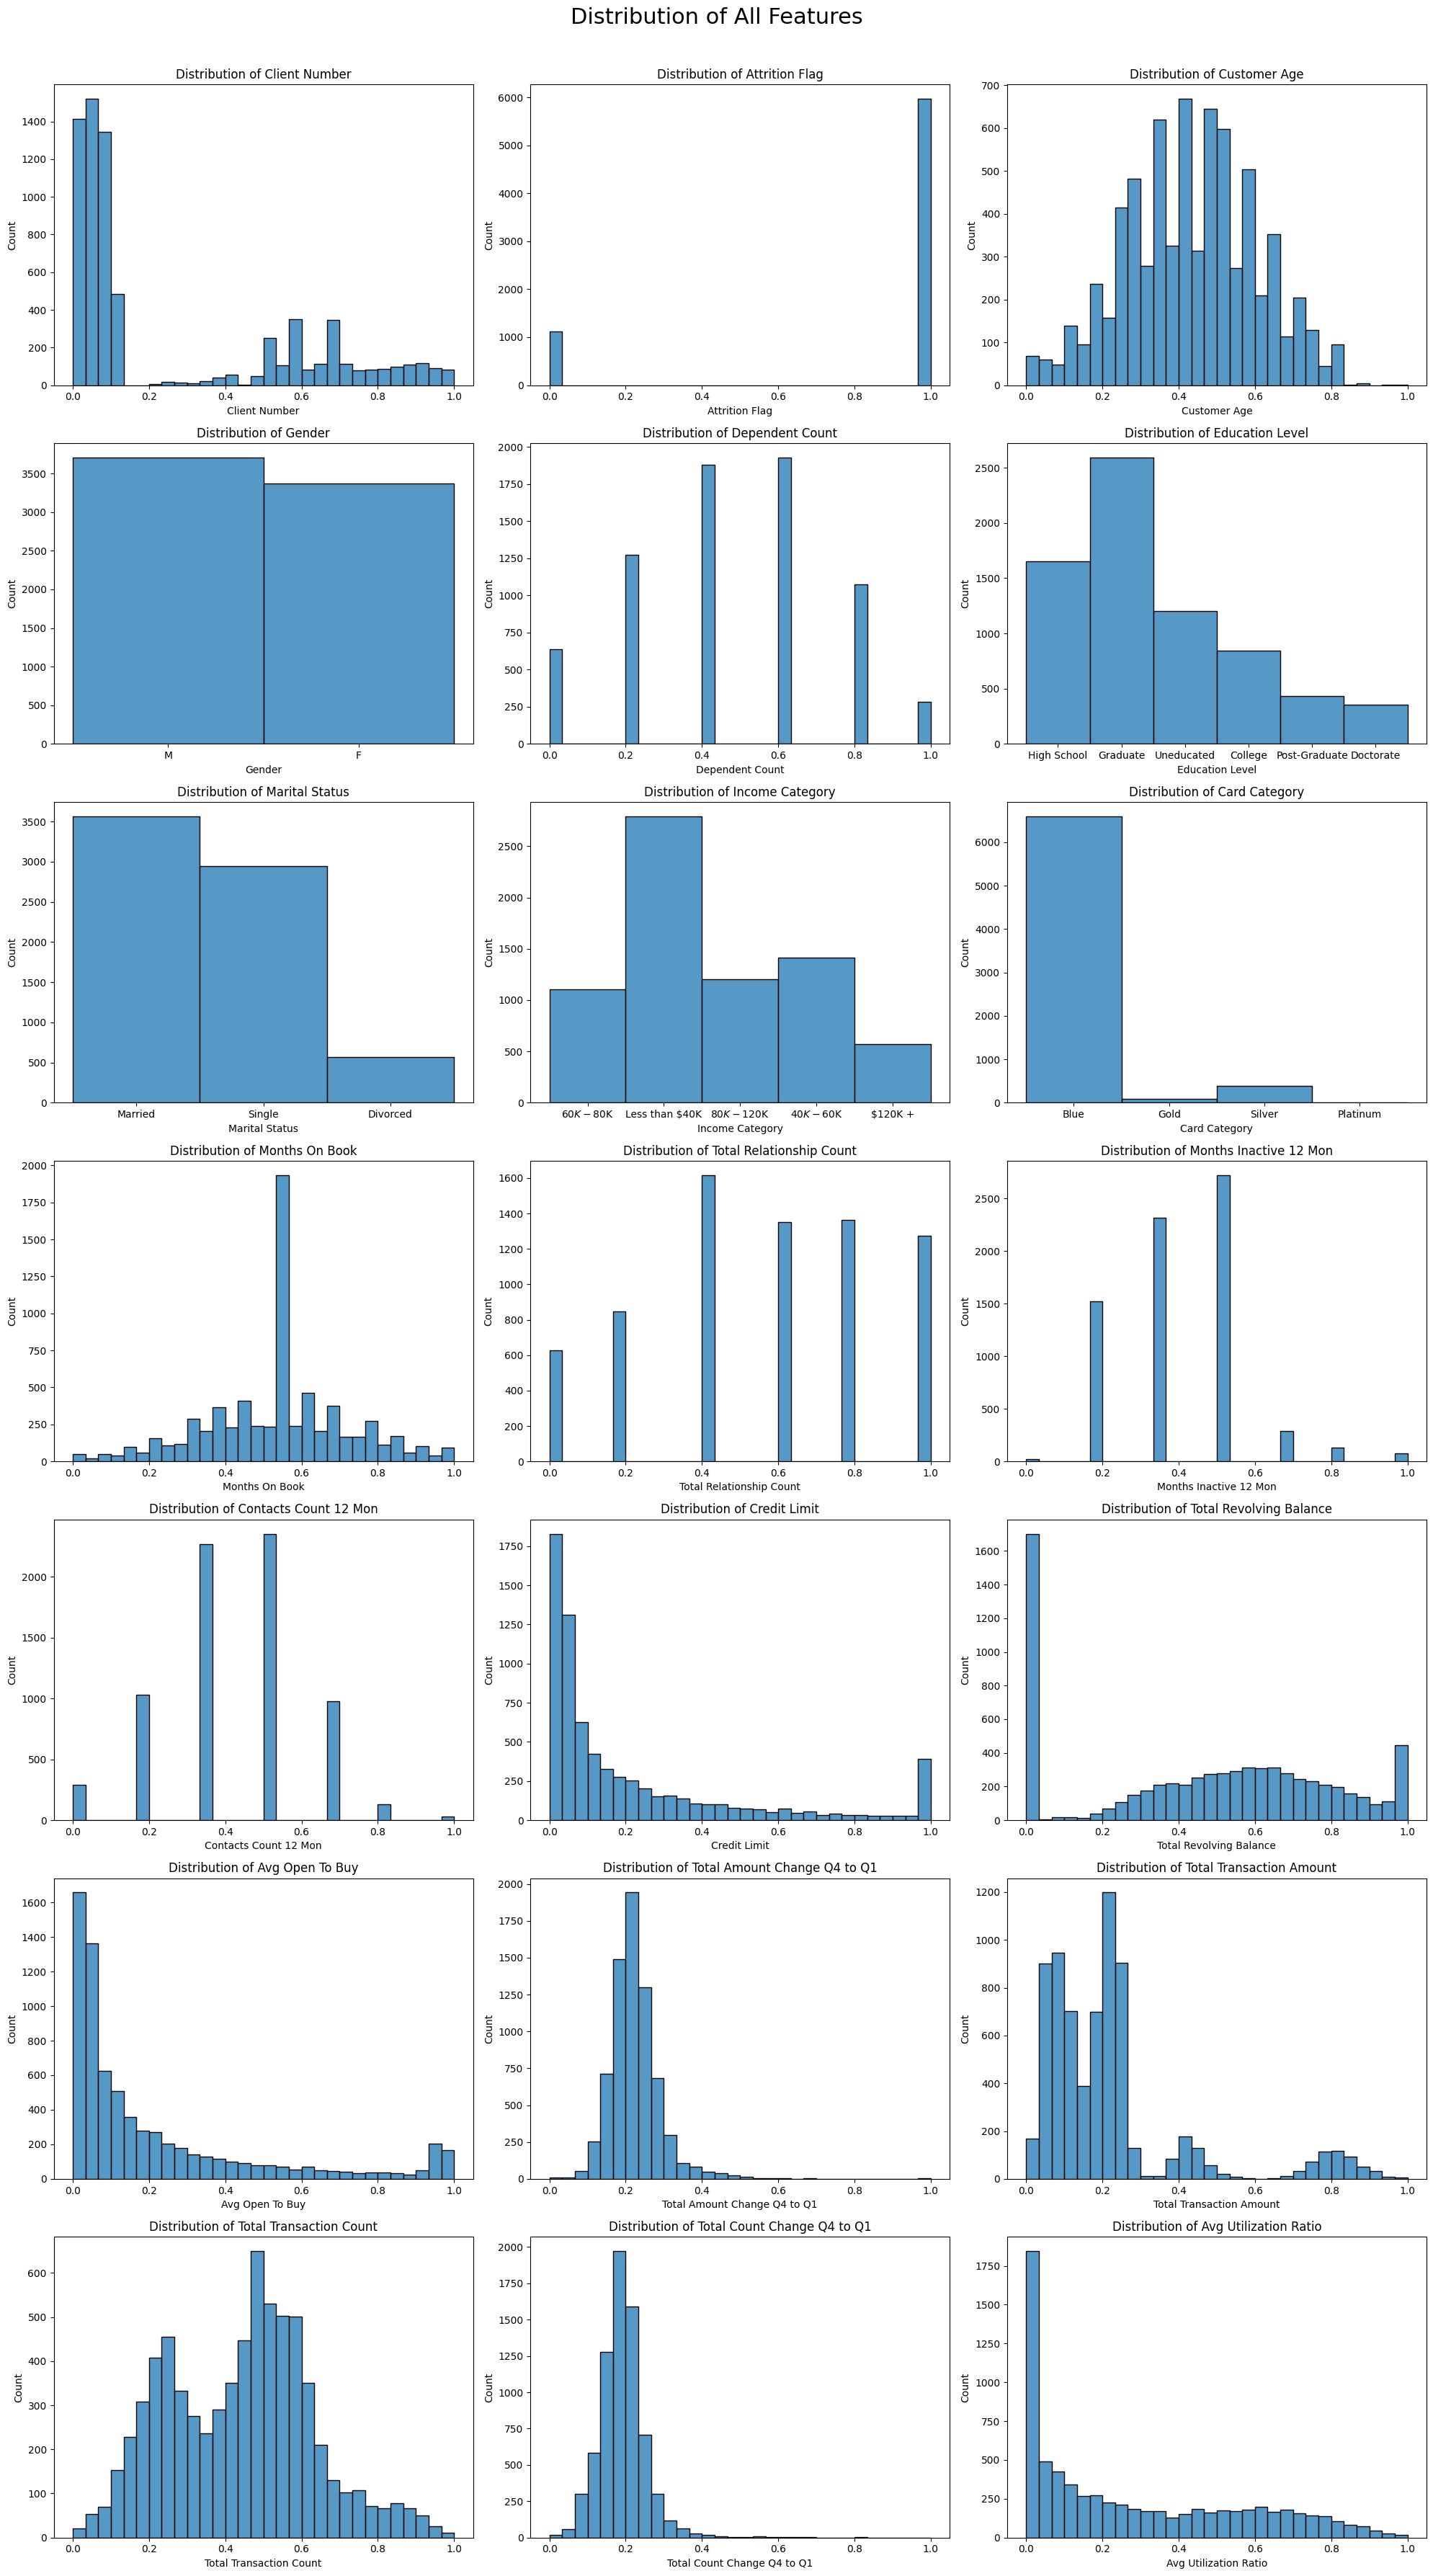

In [ ]:
# -----------------------------------
# 4.0 Exploratory Data Analysis (EDA)
# -----------------------------------

# 4.1 Distribution of all features

plt.figure(figsize=(20, 35))
for i, col in enumerate(df.columns):
    plt.subplot((len(df.columns) + 2) // 3, 3, i + 1)
    sns.histplot(df[col], kde=False, bins=30)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.suptitle('Distribution of All Features', fontsize=22, y=1.02)
plt.show()

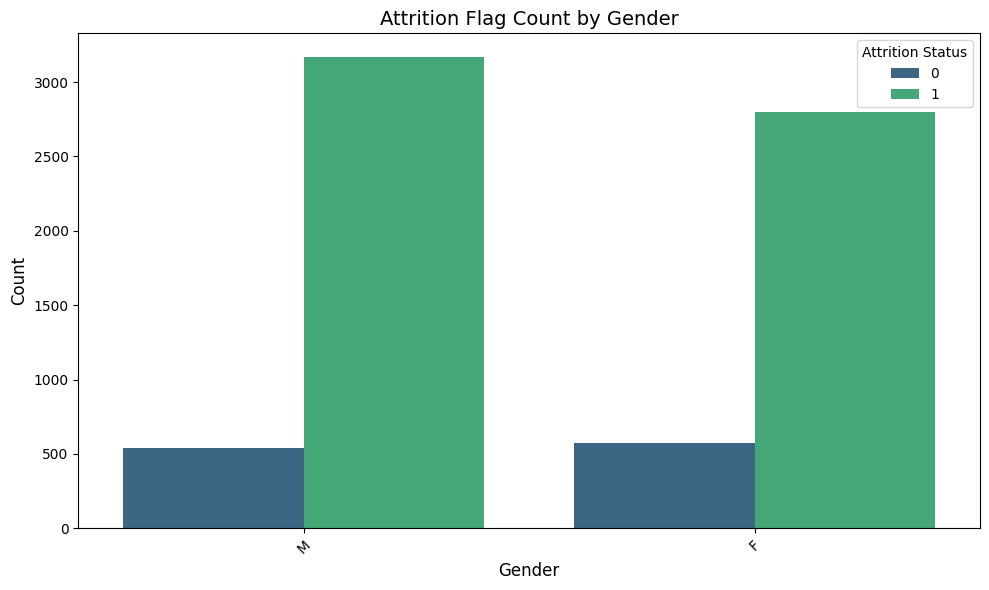

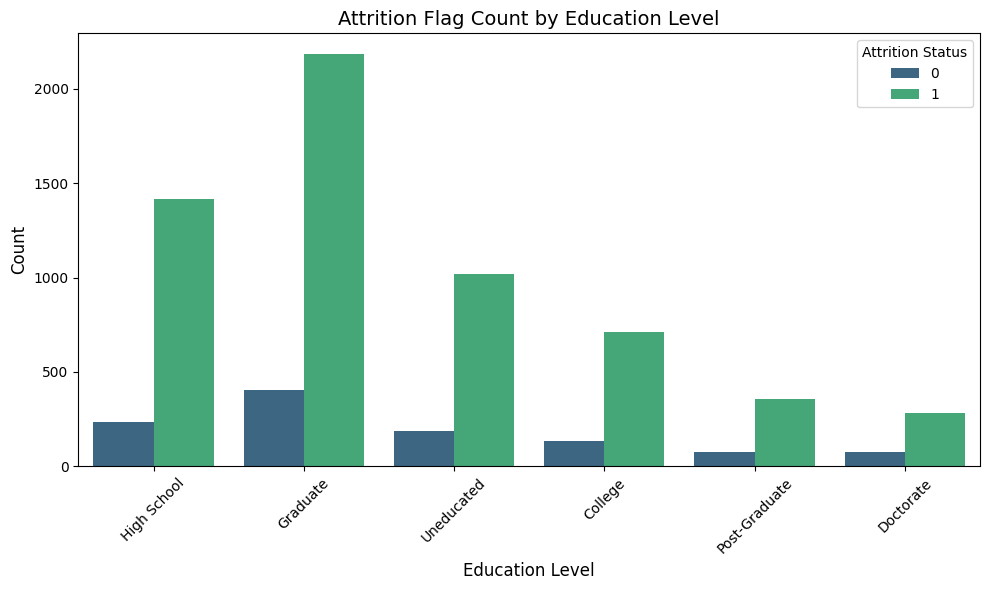

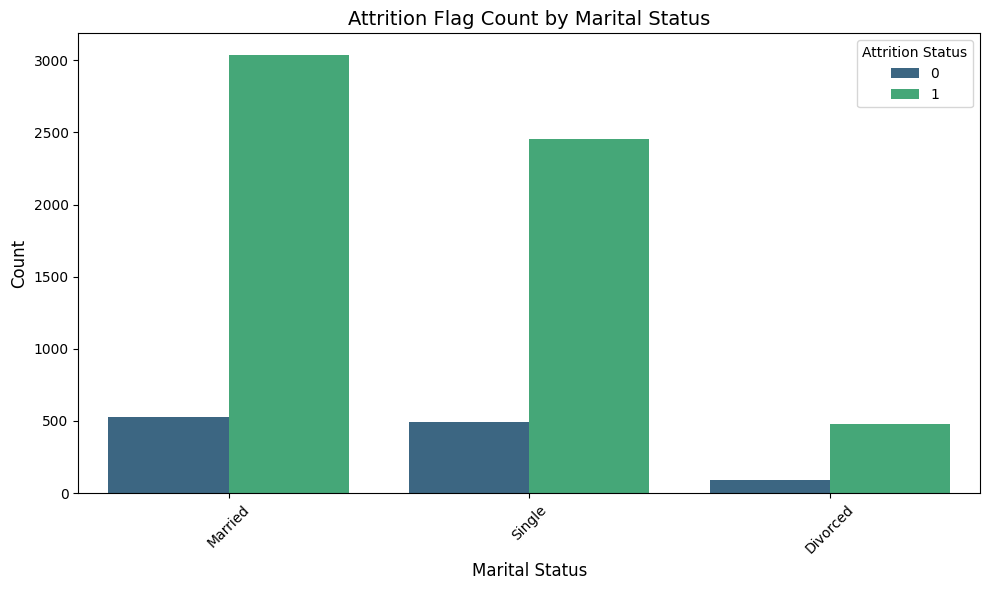

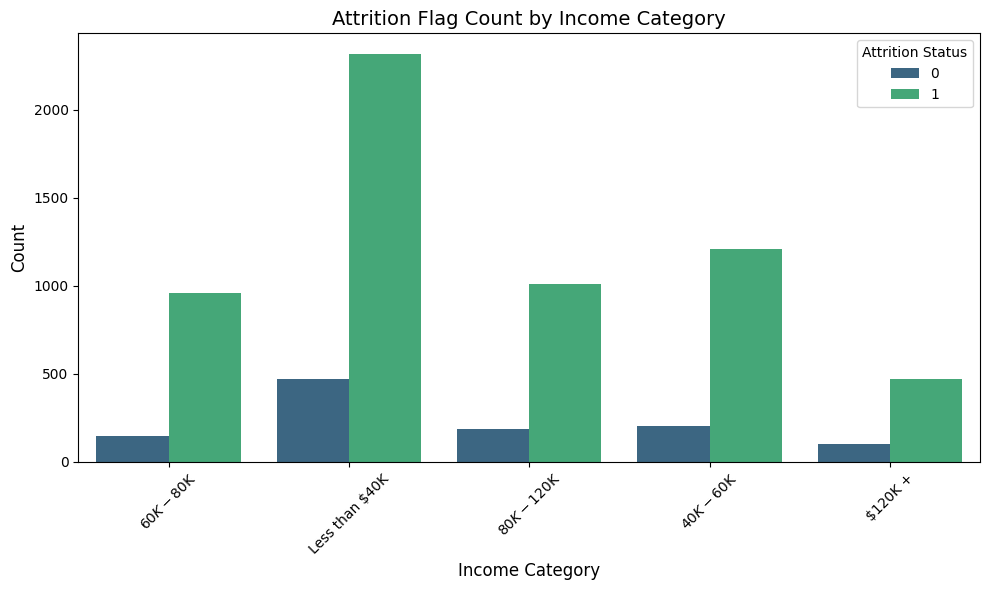

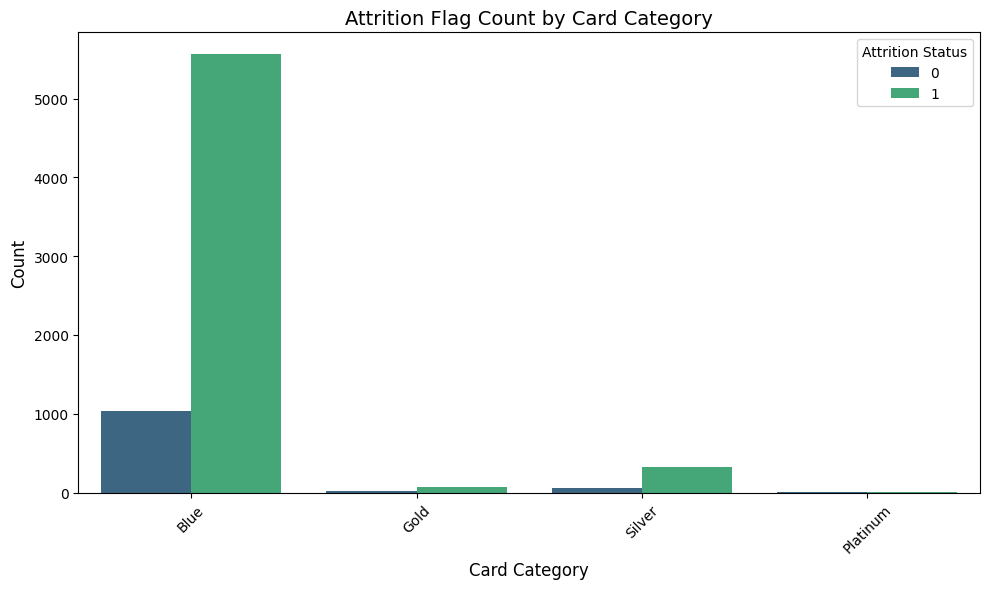

In [ ]:
# 4.2 Count of Attrition Flag by each Categorical Feature

for col in df.columns:
    if col != 'Attrition Flag' and df[col].dtype in ['object', 'category']:
        plt.figure(figsize=(10, 6))

        # Create a count plot with hue='Attrition_Flag'
        sns.countplot(
            x=col,
            hue='Attrition Flag',  # Splits bars by attrition status
            data=df,
            palette='viridis'
        )

        plt.title(f'Attrition Flag Count by {col}', fontsize=14)
        plt.xlabel(col, fontsize=12)
        plt.ylabel('Count', fontsize=12)
        plt.xticks(rotation=45)
        plt.legend(title='Attrition Status')
        plt.tight_layout()
        plt.show()

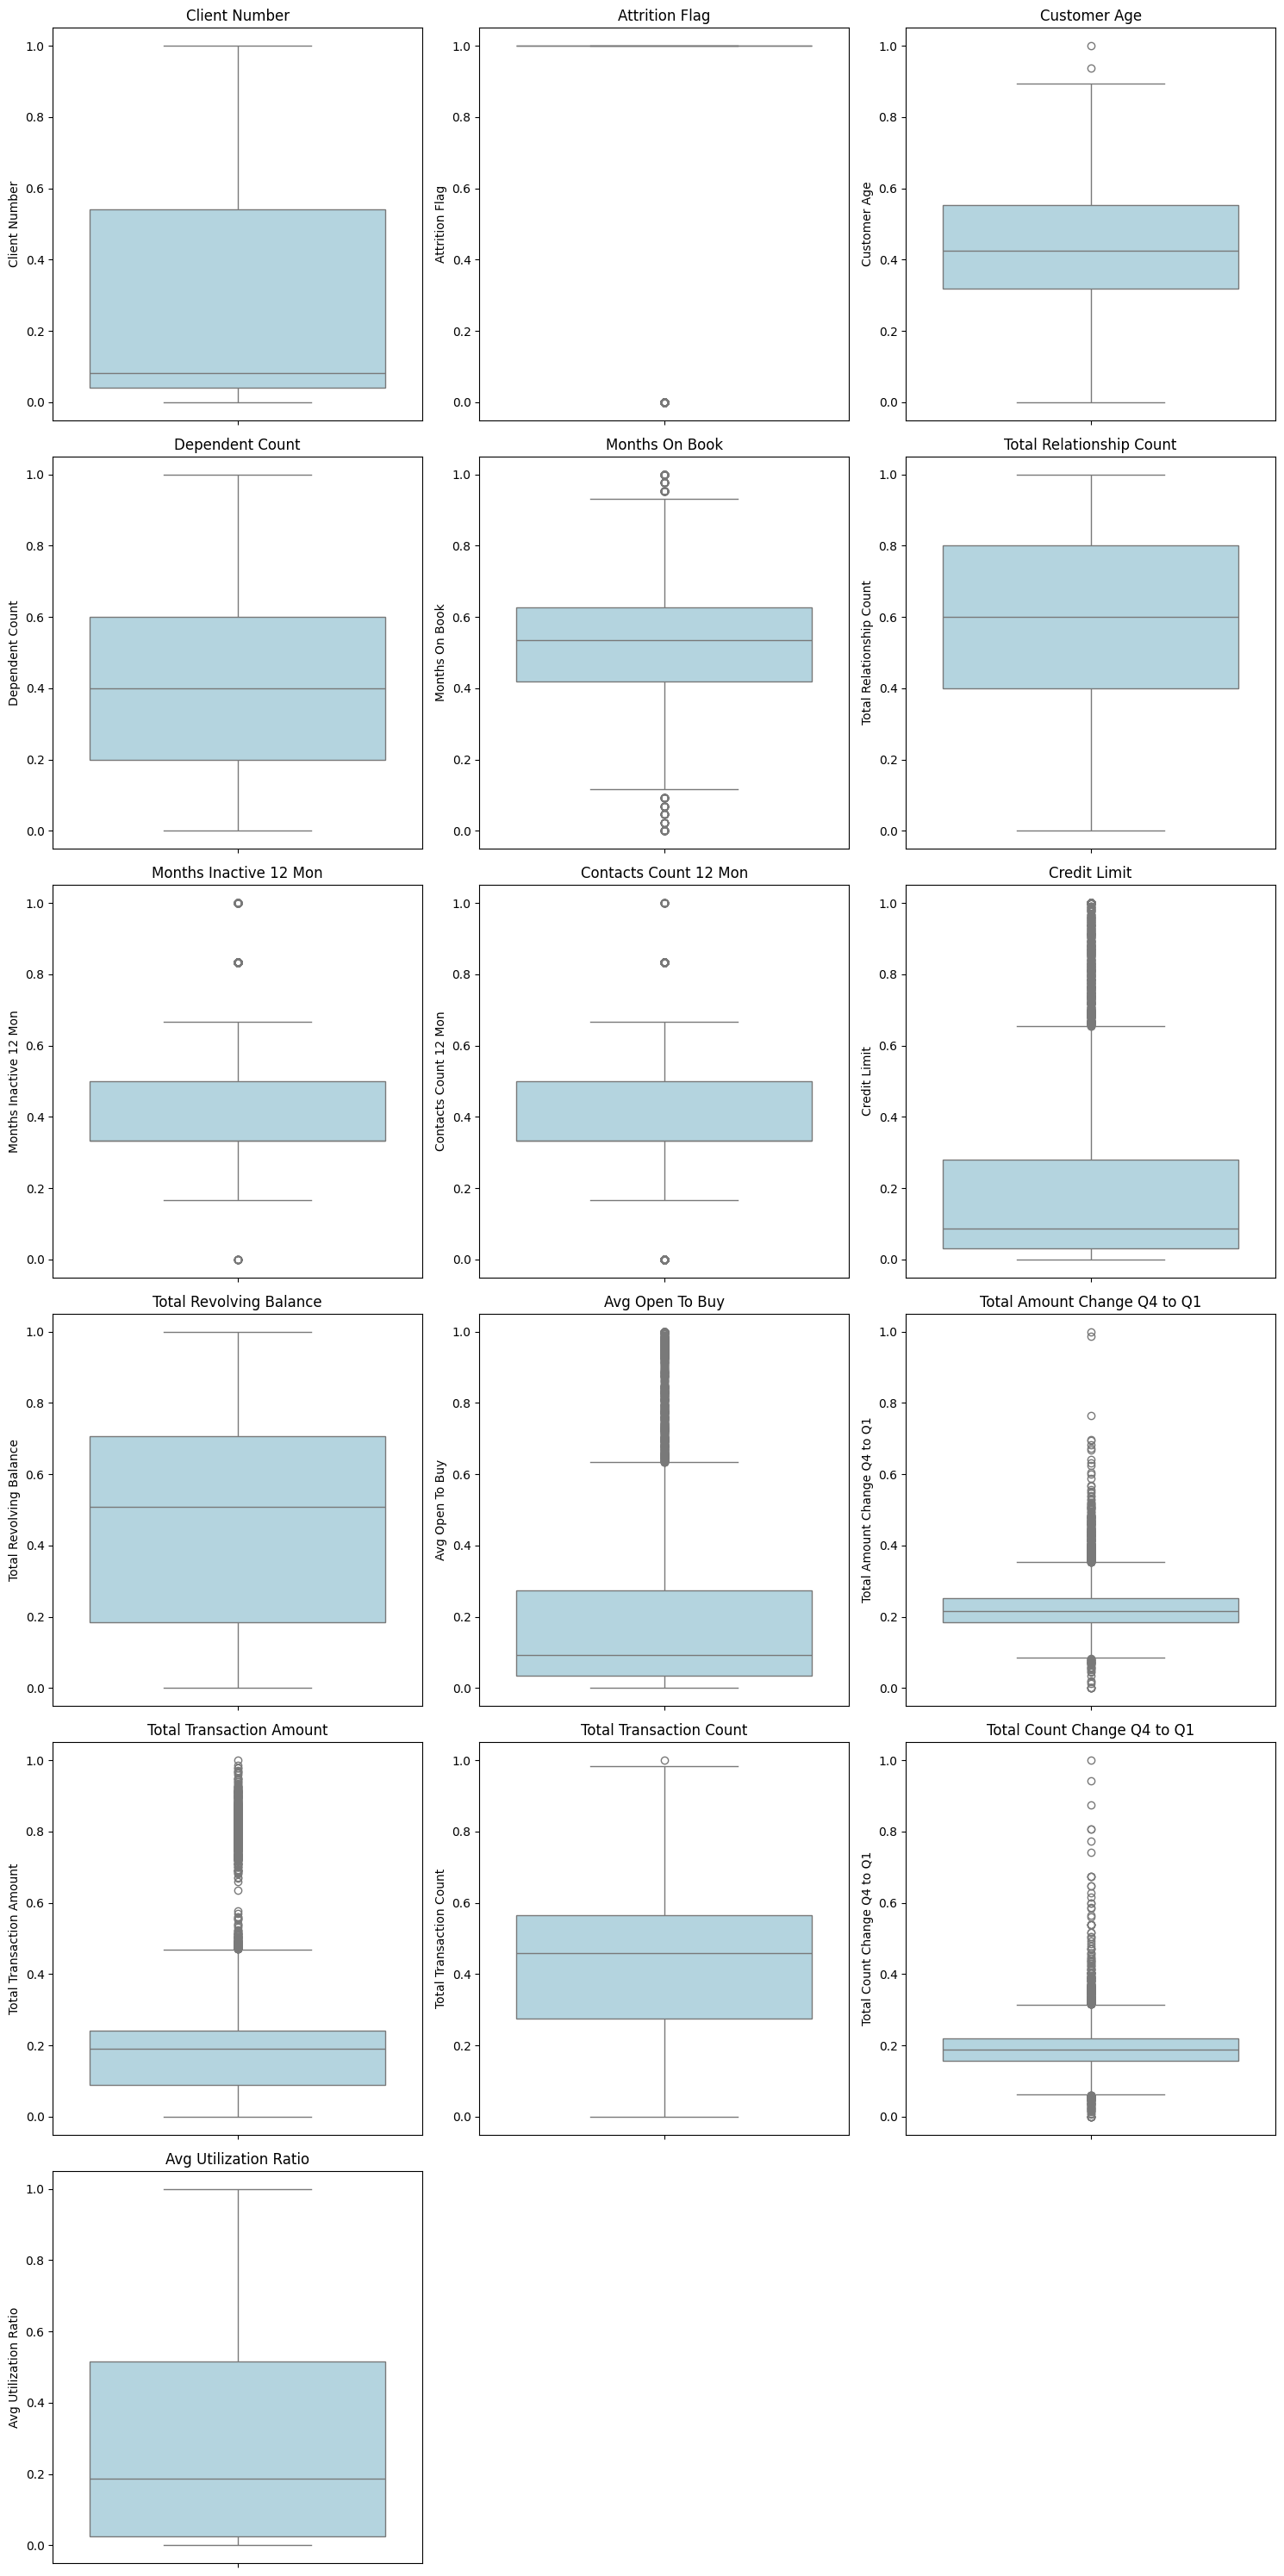

In [ ]:
# 4.3 Boxplot to Identify Outliers
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3  # Number of columns per row
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(y=df[col], color='lightblue')
    plt.title(col)
plt.tight_layout()
plt.show()

The boxplot for the numeric features shows that the columns for **customer age, months on book, months inactive, counts cont 12 month** have some outliers.

Columns for **credit limit, average open to buy, total amount change Q4 to Q1, total transaction amount, total count change Q4 to Q1** have extreme outliers.

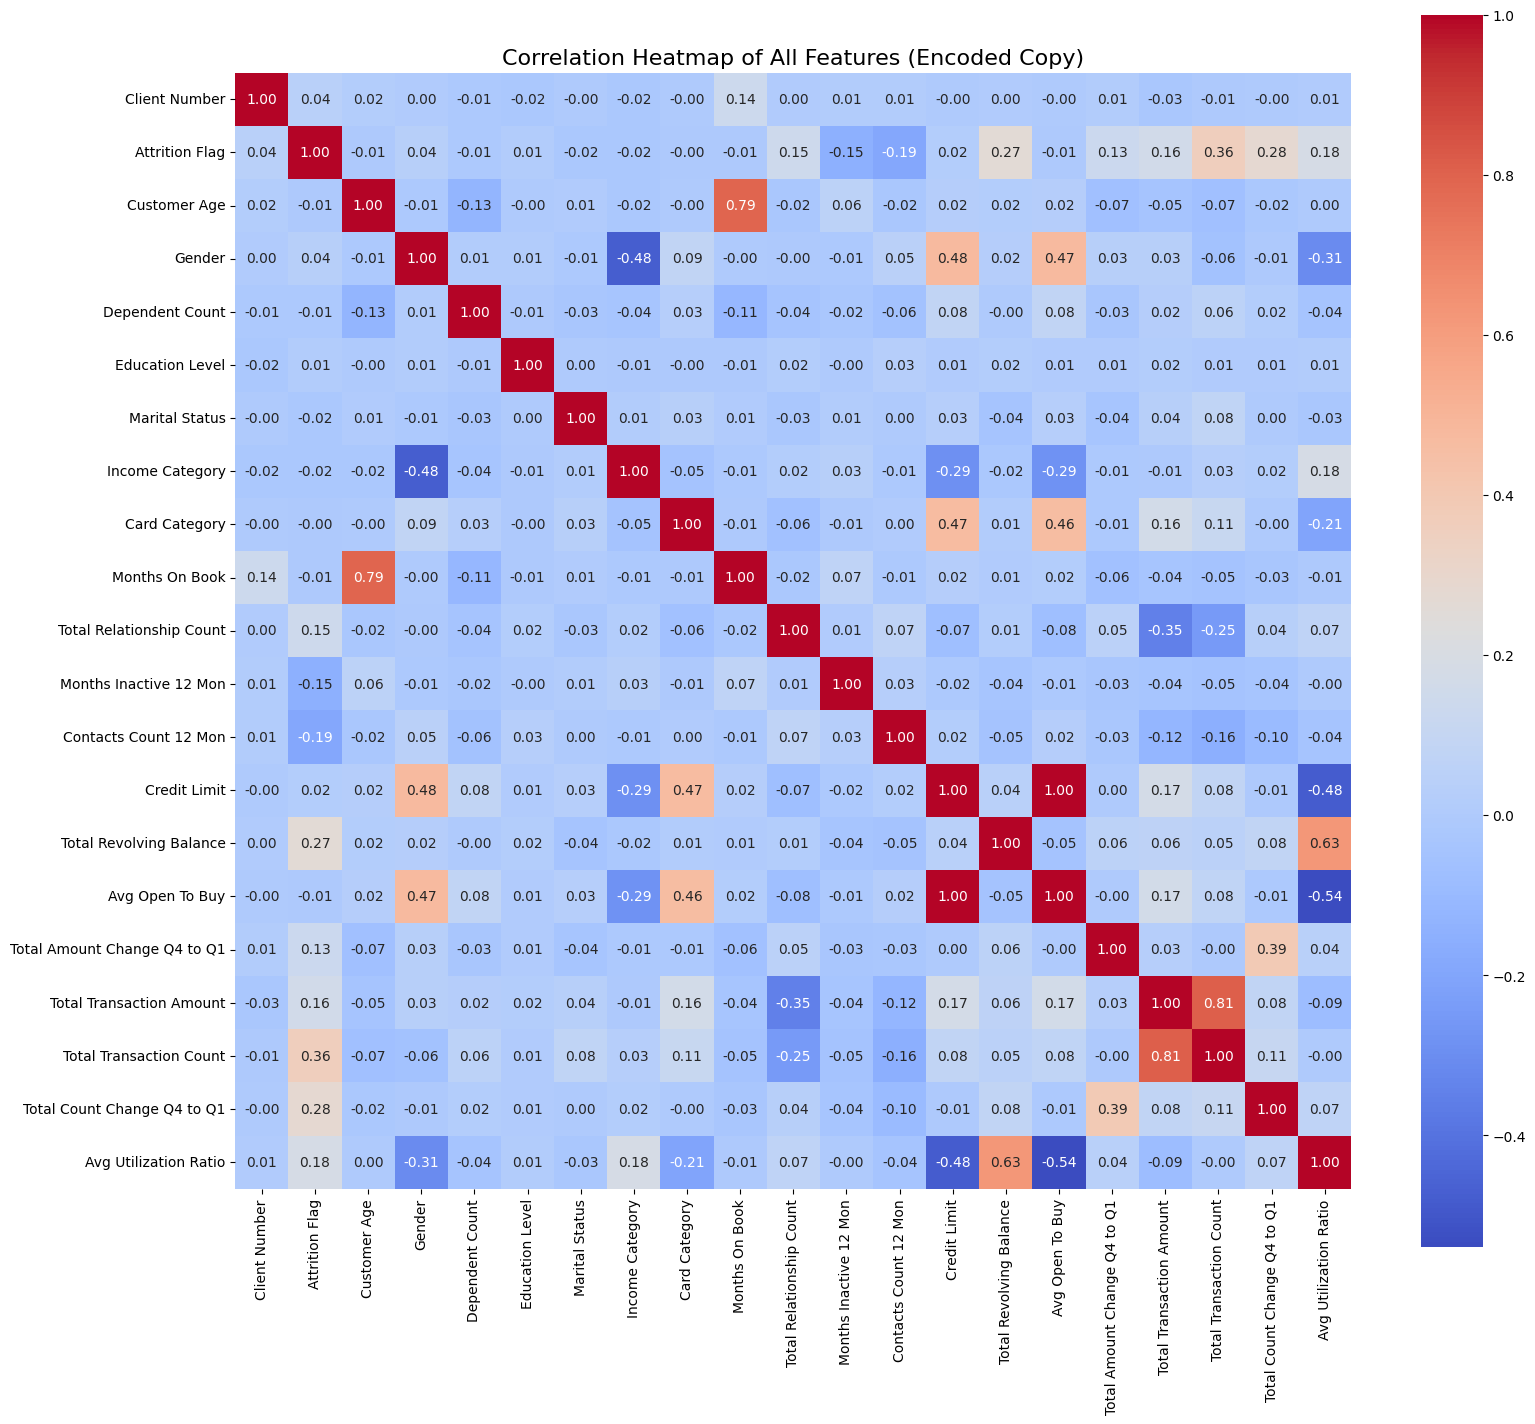

In [ ]:
# 4.4 Correlation Heatmap

df_temp = df.copy()

# Data Encoding (Data Transformation)
# Encoding all features in dataset
for col in df_temp.columns:
    if df_temp[col].dtype == 'object':  # If column is string type
        le = LabelEncoder()
        df_temp[col] = le.fit_transform(df_temp[col])

# Generate and plot the correlation heatmap
plt.figure(figsize=(18, 16))
corr = df_temp.corr()
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', square=True)
plt.title('Correlation Heatmap of All Features (Encoded Copy)', fontsize=16)
plt.show()

From the correlation heatmap, we can observe several notable patterns that could influence customer attrition:

Features such as **Total Transaction Count** , **Total Transaction Amount**, **Total Count Change Q4 to Q1**, and **Total Revolving Balance** show moderate positive correlations with Attrition Flag; , but no particular feature shows a strong direct correlation with Attrition Flag, meaning there may be indirect relationships that influence Attrition.

In contrast, **Contact Counts 12 Mon** and **Months Inactive 12 Mon** show weak negative correlation with Attrition Flag.

Additionally, financial behaviour variables such as **Credit Limit**, **Avg Open To Buy**are strongly correlated with each other, indicating potential redundanc, where as **Months On Book** and **Customer Age** strongly correlated with each other.

Non-finacial behaviour features with moderate strong correlation with financial behaviours include **Card Category**, **Customer Age**, **Income Category** and **Gender**

# Data Pre-Processing

In [ ]:
# -----------------------------------
# 4.0 Data Pre-Processing Techniques
# -----------------------------------

# 4.1 Handling Outliers

def cap_outliers(series, lower_quantile=0.01, upper_quantile=0.99):
    lower = series.quantile(lower_quantile)
    upper = series.quantile(upper_quantile)
    return series.clip(lower, upper)

# Apply to relevant columns
cols_with_extreme_outliers = [
    'Credit Limit', 'Avg Open To Buy', 'Total Amount Change Q4 to Q1',
    'Total Transaction Amount', 'Total Count Change Q4 to Q1'
]

for col in cols_with_extreme_outliers:
    df[col] = cap_outliers(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7081 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Client Number                 7081 non-null   float64
 1   Attrition Flag                7081 non-null   int64  
 2   Customer Age                  7081 non-null   float64
 3   Gender                        7081 non-null   object 
 4   Dependent Count               7081 non-null   float64
 5   Education Level               7081 non-null   object 
 6   Marital Status                7081 non-null   object 
 7   Income Category               7081 non-null   object 
 8   Card Category                 7081 non-null   object 
 9   Months On Book                7081 non-null   float64
 10  Total Relationship Count      7081 non-null   float64
 11  Months Inactive 12 Mon        7081 non-null   float64
 12  Contacts Count 12 Mon         7081 non-null   float64
 13  Credit 

In [ ]:
# 2.4 Feature Engineering
# Feature Selection

# Through the the heat correlation map as well as research done of this topic, columns including 'Client Number', 'Education Level', 'Maritial Status', 'Card Category' and 'Dependent Count' will dropped due to it showing very little correlation attrition
# Average Open to Buy will also be dropped as it shows little correlation and has a perfect correlation with Credit Limit

# Step 1: Manual Feature Dropping based on correlation and multicollinearity
columns_to_drop = [
    'Client Number',        # Identifier
    'Education Level',      # Low correlation
    'Marital Status',       # Low correlation
    'Card Category',        # Low correlation
    'Dependent Count',      # Low correlation
    'Avg Open To Buy'       # Perfect correlation with Credit Limit
]

# Drop only columns in df
columns_to_drop = [col for col in columns_to_drop if col in df.columns]

print(f"Shape before dropping columns: {df.shape}")
df.drop(columns=columns_to_drop, axis=1, inplace=True)
print(f"Shape after dropping columns: {df.shape}")

# Encoding remaining categorical features before feature selection
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])

# Selecting top 5 features using SelectKBest
X = df.drop('Attrition Flag', axis=1)
y = df['Attrition Flag']

k = 5
skb = SelectKBest(score_func=f_classif, k=k)
X_new = skb.fit_transform(X, y)

# Get names of selected top 5 features
mask = skb.get_support()
top_k_features = X.columns[mask].tolist()

print(f"\nTop {k} features selected by SelectKBest:")
print(top_k_features)

Shape before dropping columns: (7081, 21)
Shape after dropping columns: (7081, 15)

Top 5 features selected by SelectKBest:
['Contacts Count 12 Mon', 'Total Revolving Balance', 'Total Transaction Count', 'Total Count Change Q4 to Q1', 'Avg Utilization Ratio']


Class Distribution (Normalized):
Attrition Flag
1    0.842819
0    0.157181
Name: proportion, dtype: float64
-----With SMOTE-----
Best parameters: {'model__max_depth': 20, 'model__n_estimators': 150}
Best CV score: 0.9537451775984829

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87       212
           1       0.98      0.97      0.98      1205

    accuracy                           0.96      1417
   macro avg       0.92      0.93      0.92      1417
weighted avg       0.96      0.96      0.96      1417


-----Without SMOTE, Class_weight='balanced'-----
Best parameters: {'model__max_depth': 30, 'model__n_estimators': 150}
Best CV score: 0.9540977547958919

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.79      0.85       212
           1       0.96      0.99      0.98      1205

    accuracy                           0.96      1417
   macro avg     

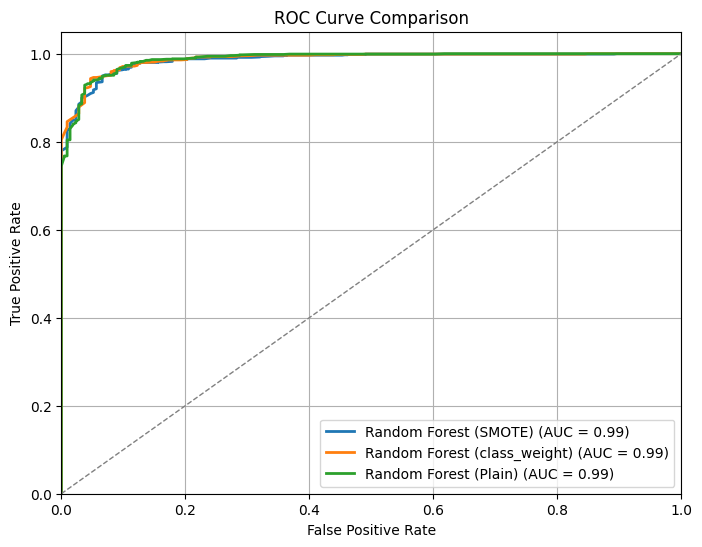

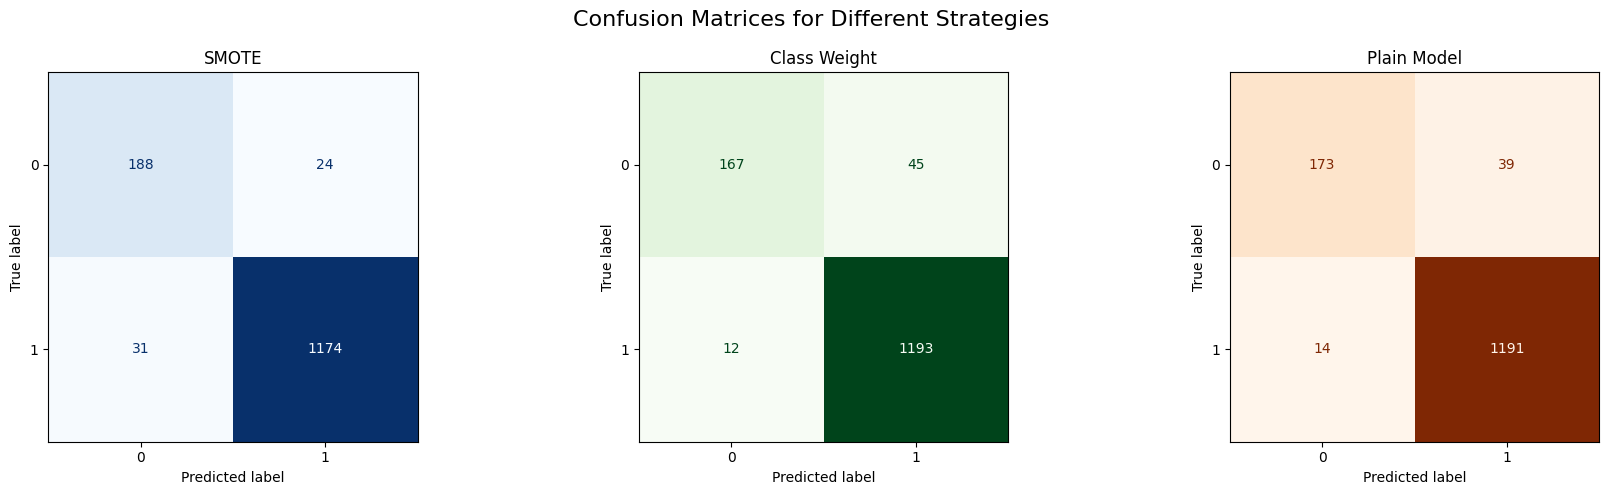

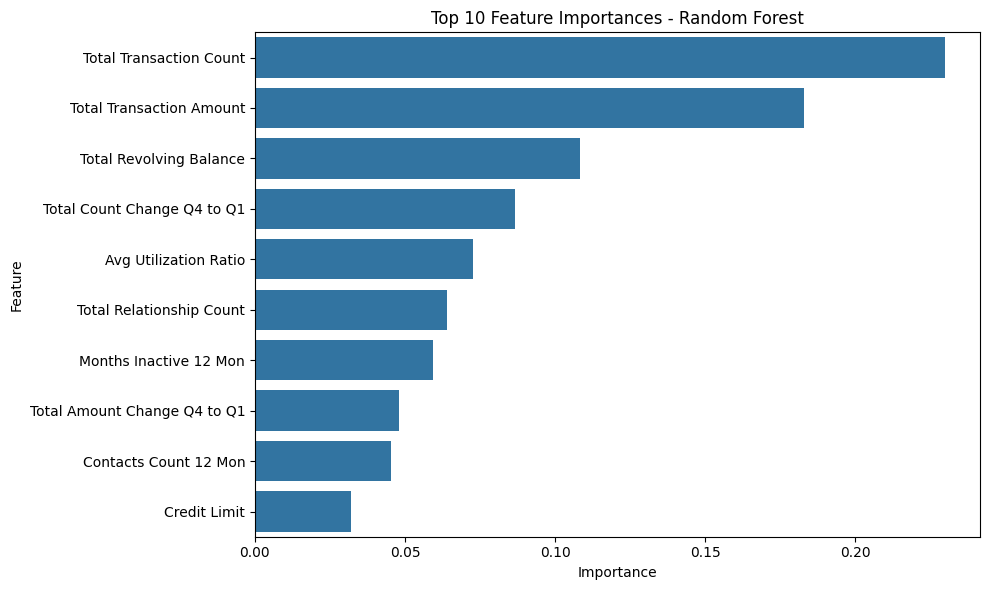

In [ ]:
 import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.pipeline import Pipeline as Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline as SkPipeline
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Prepare data
target = 'Attrition Flag'
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

print("Class Distribution (Normalized):")
print(y.value_counts(normalize=True))

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define parameter grid
param_grid = {
    'model__n_estimators': [100, 150],
    'model__max_depth': [10, 20, 30]
}

# Model 1: With SMOTE
pipe_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])
grid_smote = GridSearchCV(pipe_smote, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_smote.fit(X_train, y_train)
y_pred_smote = grid_smote.predict(X_test)
print("-----With SMOTE-----")
print("Best parameters:", grid_smote.best_params_)
print("Best CV score:", grid_smote.best_score_)
print("\nClassification Report:\n", classification_report(y_test, y_pred_smote))

# Model 2: Without SMOTE but with class_weight='balanced'
pipe_weighted = SkPipeline([
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])
grid_weighted = GridSearchCV(pipe_weighted, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_weighted.fit(X_train, y_train)
y_pred_weighted = grid_weighted.predict(X_test)
print("\n-----Without SMOTE, Class_weight='balanced'-----")
print("Best parameters:", grid_weighted.best_params_)
print("Best CV score:", grid_weighted.best_score_)
print("\nClassification Report:\n", classification_report(y_test, y_pred_weighted))

# Model 3: Without SMOTE and without class_weight
pipe_plain = SkPipeline([
    ('model', RandomForestClassifier(random_state=42))
])
grid_plain = GridSearchCV(pipe_plain, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_plain.fit(X_train, y_train)
y_pred_plain = grid_plain.predict(X_test)
print("\n-----Without SMOTE, Without Class Weight-----")
print("Best parameters:", grid_plain.best_params_)
print("Best CV score:", grid_plain.best_score_)
print("\nClassification Report:\n", classification_report(y_test, y_pred_plain))


# Plot ROC comparison
def plot_roc_comparison(models_with_names, X_test, y_test):
    plt.figure(figsize=(8, 6))
    for model, name in models_with_names:
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Plot ROC for all 3 models
models_with_names = [
    (grid_smote.best_estimator_, 'Random Forest (SMOTE)'),
    (grid_weighted.best_estimator_, 'Random Forest (class_weight)'),
    (grid_plain.best_estimator_, 'Random Forest (Plain)')
]

plot_roc_comparison(models_with_names, X_test, y_test)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrices
cm_smote = confusion_matrix(y_test, y_pred_smote)
cm_weight = confusion_matrix(y_test, y_pred_weighted)
cm_plain = confusion_matrix(y_test, y_pred_plain)

# Get labels (assumes binary classification with 0 and 1)
labels = grid_plain.best_estimator_.named_steps['model'].classes_

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot SMOTE confusion matrix
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=labels)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('SMOTE')

# Plot class_weight confusion matrix
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_weight, display_labels=labels)
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Class Weight')

# Plot plain model confusion matrix
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_plain, display_labels=labels)
disp3.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('Plain Model')

# Layout adjustments
plt.suptitle('Confusion Matrices for Different Strategies', fontsize=16)
plt.tight_layout()
plt.show()

# Get the trained model from pipeline
rf_model = grid_smote.best_estimator_.named_steps['model']

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Create DataFrame for easy plotting
import pandas as pd
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot top 10 features
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Shared setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
X_np = X.to_numpy()
y_np = y.to_numpy()

# Scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'recall_0': make_scorer(recall_score, pos_label=0),
    'recall_1': make_scorer(recall_score, pos_label=1),
    'f1_0': make_scorer(f1_score, pos_label=0),
    'f1_1': make_scorer(f1_score, pos_label=1)
}

# Evaluation function
def evaluate_pipeline(pipeline, X, y, label):
    results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)
    df = pd.Series({f"test_{k}": round(results[f'test_{k}'].mean(), 6) for k in scoring})
    df.name = label
    return df

# Model 1:  Plain Random Forest
pipe_plain_rf = Pipeline([
    ('scaler', scaler),
    ('model', RandomForestClassifier(random_state=42))
])

# Model 2: Random Forest with class_weight='balanced'
pipe_weight_rf = Pipeline([
    ('scaler', scaler),
    ('model', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Model 3:  Random Forest with SMOTE
pipe_smote_rf = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', scaler),
    ('model', RandomForestClassifier(random_state=42))
])

# Run all 3 evaluations
results_plain_rf = evaluate_pipeline(pipe_plain_rf, X_np, y_np, "RF - Plain")
results_weight_rf = evaluate_pipeline(pipe_weight_rf, X_np, y_np, "RF - Class Weight")
results_smote_rf = evaluate_pipeline(pipe_smote_rf, X_np, y_np, "RF - SMOTE")

# Combine into table
rf_results_df = pd.concat([results_plain_rf, results_weight_rf, results_smote_rf], axis=1)
print(rf_results_df)

               RF - Plain  RF - Class Weight  RF - SMOTE
test_accuracy    0.960174           0.956361    0.957350
test_f1_macro    0.920983           0.911535    0.920326
test_recall_0    0.813994           0.778071    0.875999
test_recall_1    0.987433           0.989611    0.972519
test_f1_0        0.865335           0.848565    0.866015
test_f1_1        0.976631           0.974505    0.974637


Result shows it is not overfitting data, and with the use of smote increased 10% recall gain. slight trade off for class 1 recall from 0.99 to 0.97.

Among the three Random Forest configurations tested, the version trained with SMOTE achieved the highest recall and F1-score for the minority class (churners), making it the most suitable choice for this churn prediction task, where identifying at-risk customers is a primary goal.

-----With SMOTE-----
Best Parameters: {'model__C': 1, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Score: 0.8396904306712534

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.84      0.62       212
           1       0.97      0.85      0.90      1205

    accuracy                           0.85      1417
   macro avg       0.73      0.84      0.76      1417
weighted avg       0.90      0.85      0.86      1417


-----Without SMOTE, class_weight='balanced'-----
Best Parameters: {'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best CV Score: 0.8326279710203688

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.83      0.60       212
           1       0.97      0.84      0.90      1205

    accuracy                           0.84      1417
   macro avg       0.72      0.83      0.75      1417
weighted avg       0.89      0.84      0.85    

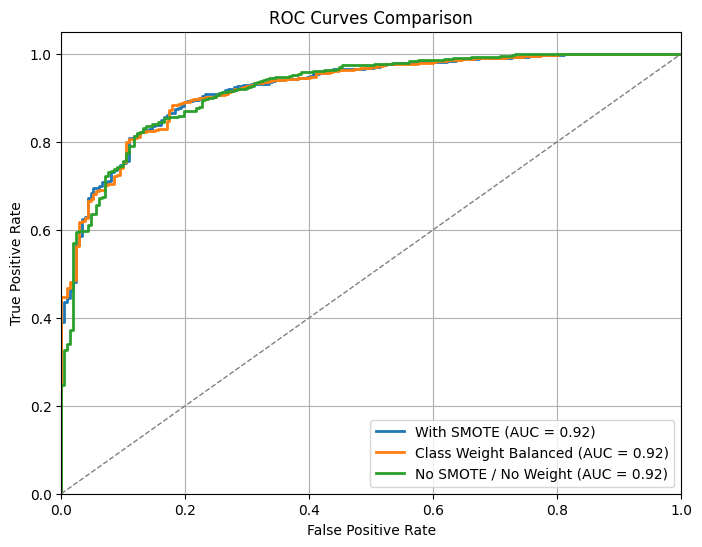

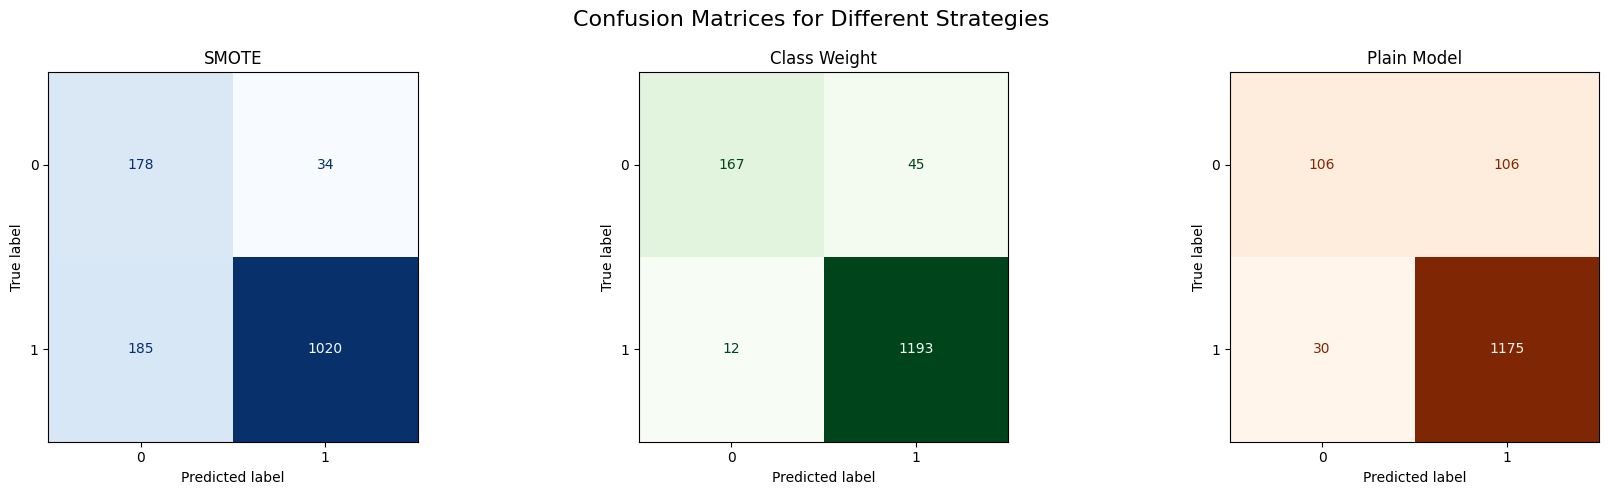

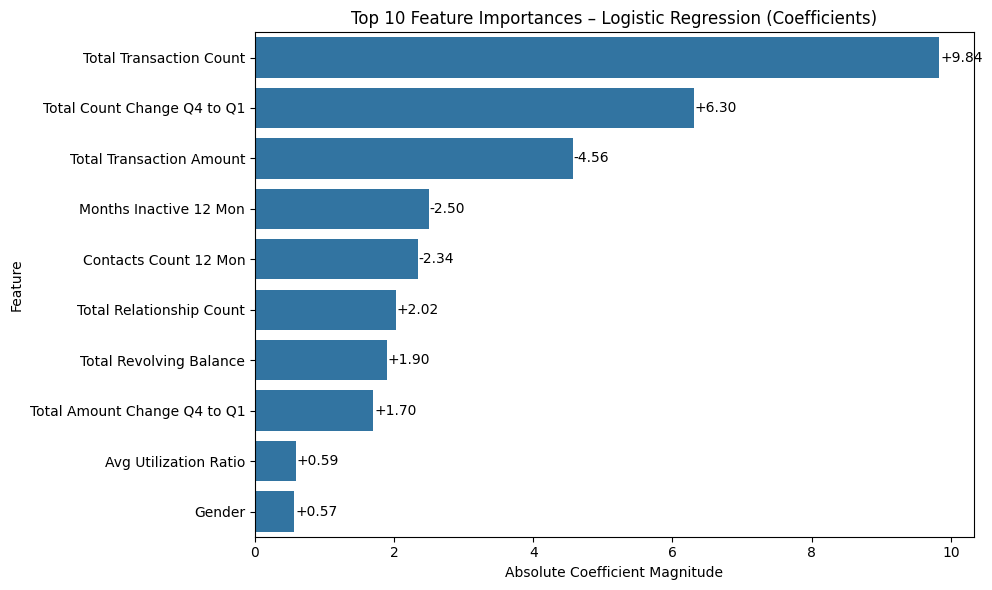

In [ ]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline as SkPipeline

# Split features and target
target = 'Attrition Flag'
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to plot ROC curves for multiple models
def plot_roc_curves(models):
    plt.figure(figsize=(8, 6))
    for model, name in models:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Common parameter grid
param_grid = {
    'model__C': [0.01, 0.1, 1, 10],
    'model__penalty': ['l2'],
    'model__solver': ['lbfgs']
}

# With SMOTE
pipe_smote = Pipeline([
    ('smote', SMOTE()),
    ('model', LogisticRegression(class_weight='balanced'))
])
grid_smote = GridSearchCV(pipe_smote, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_smote.fit(X_train, y_train)

print("-----With SMOTE-----")
print("Best Parameters:", grid_smote.best_params_)
print("Best CV Score:", grid_smote.best_score_)
y_pred_smote = grid_smote.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))


# Without SMOTE, with class_weight='balanced'
pipe_weight = SkPipeline([
    ('model', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])
grid_weight = GridSearchCV(pipe_weight, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_weight.fit(X_train, y_train)

print("\n-----Without SMOTE, class_weight='balanced'-----")
print("Best Parameters:", grid_weight.best_params_)
print("Best CV Score:", grid_weight.best_score_)
y_pred_weight = grid_weight.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_weight))


# Without SMOTE and without class weight
pipe_plain = SkPipeline([
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
grid_plain = GridSearchCV(pipe_plain, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_plain.fit(X_train, y_train)

print("\n-----Without SMOTE, Without Class Weight-----")
print("Best Parameters:", grid_plain.best_params_)
print("Best CV Score:", grid_plain.best_score_)
y_pred_plain = grid_plain.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_plain))


# Plot all ROC curves together
plot_roc_curves([
    (grid_smote.best_estimator_, "With SMOTE"),
    (grid_weight.best_estimator_, "Class Weight Balanced"),
    (grid_plain.best_estimator_, "No SMOTE / No Weight")
])
# Compute confusion matrices
cm_smote = confusion_matrix(y_test, y_pred_smote)
cm_weight = confusion_matrix(y_test, y_pred_weighted)
cm_plain = confusion_matrix(y_test, y_pred_plain)

# Get labels (assumes binary classification with 0 and 1)
labels = grid_plain.best_estimator_.named_steps['model'].classes_

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot SMOTE confusion matrix
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=labels)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('SMOTE')

# Plot class_weight confusion matrix
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_weight, display_labels=labels)
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Class Weight')

# Plot plain model confusion matrix
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_plain, display_labels=labels)
disp3.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('Plain Model')

# Layout adjustments
plt.suptitle('Confusion Matrices for Different Strategies', fontsize=16)
plt.tight_layout()
plt.show()

# Extract best logistic regression model from pipeline
logreg_model = grid_plain.best_estimator_.named_steps['model']

# Get feature names and coefficients
feature_names = X.columns
coefs = logreg_model.coef_[0]

# Create DataFrame of features and coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    'Importance (Abs)': np.abs(coefs)
})

# Sort and select top features
importance_df = importance_df.sort_values(by='Importance (Abs)', ascending=False).head(10)
importance_df['Rounded Coef'] = importance_df['Coefficient'].round(3)

# Reset index so seaborn uses 0–9 ordering
importance_df = importance_df.reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x='Importance (Abs)',
    y='Feature',
    data=importance_df
)

# Annotate with signed coefficient values
for bar_idx, coef in enumerate(importance_df['Rounded Coef']):
    ax.text(
        importance_df['Importance (Abs)'][bar_idx] + 0.01,
        bar_idx,
        f"{coef:+.2f}",  # Display e.g. +0.34 or -0.57
        va='center',
        color='black',
        fontsize=10
    )

plt.title("Top 10 Feature Importances – Logistic Regression (Coefficients)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
#using stratifiedKFold and crossValidate to verify result is not overfitted
from sklearn.model_selection import StratifiedKFold, cross_validate
from imblearn.pipeline import Pipeline as Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score, accuracy_score
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Set up common variables
scaler = StandardScaler()
X_np = X.to_numpy()
y_np = y.to_numpy()

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Function to evaluate a pipeline using Stratified K-Fold
def evaluate_pipeline(pipeline, X, y, label):
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'recall_0': make_scorer(recall_score, pos_label=0),
        'recall_1': make_scorer(recall_score, pos_label=1),
        'f1_0': make_scorer(f1_score, pos_label=0),
        'f1_1': make_scorer(f1_score, pos_label=1)
    }
    results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)
    df = pd.Series({f"test_{k}": round(results[f'test_{k}'].mean(), 6) for k in scoring})
    df.name = label
    return df

# Model 1: Plain Logistic Regression (no balancing)
pipe_plain = Pipeline([
    ('scaler', scaler),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Model 2: Logistic Regression with class_weight='balanced'
pipe_weight = Pipeline([
    ('scaler', scaler),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Model 3: Logistic Regression with SMOTE
pipe_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', scaler),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# Run all 3
results_plain = evaluate_pipeline(pipe_plain, X_np, y_np, "LogReg - Plain")
results_weight = evaluate_pipeline(pipe_weight, X_np, y_np, "LogReg - Class Weight")
results_smote = evaluate_pipeline(pipe_smote, X_np, y_np, "LogReg - SMOTE")

# Combine into one table
lr_results_df = pd.concat([results_plain, results_weight, results_smote], axis=1)
print(lr_results_df)

               LogReg - Plain  LogReg - Class Weight  LogReg - SMOTE
test_accuracy        0.898884               0.834203        0.840417
test_f1_macro        0.784496               0.752415        0.758202
test_recall_0        0.541757               0.824829        0.818543
test_recall_1        0.965480               0.835956        0.844502
test_f1_0            0.627509               0.610132        0.617224
test_f1_1            0.941483               0.894698        0.899180


Result shows SMOTE does not provide any significant improvement, where class 0 prediction quality (f1) is low even with SMOTE, RandomForest performs better overall compared to Logistic Regression.



-----With SMOTE-----
Best Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV Score: 0.9899980168480347

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       212
           1       0.98      0.98      0.98      1205

    accuracy                           0.97      1417
   macro avg       0.93      0.94      0.93      1417
weighted avg       0.97      0.97      0.97      1417


-----Without SMOTE,With scale_pos_weight-----
Best Parameters: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
Best CV Score: 0.9917166384234605

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.92      0.87       212
           1       0.99      0.97      0.98      1205

    accuracy   

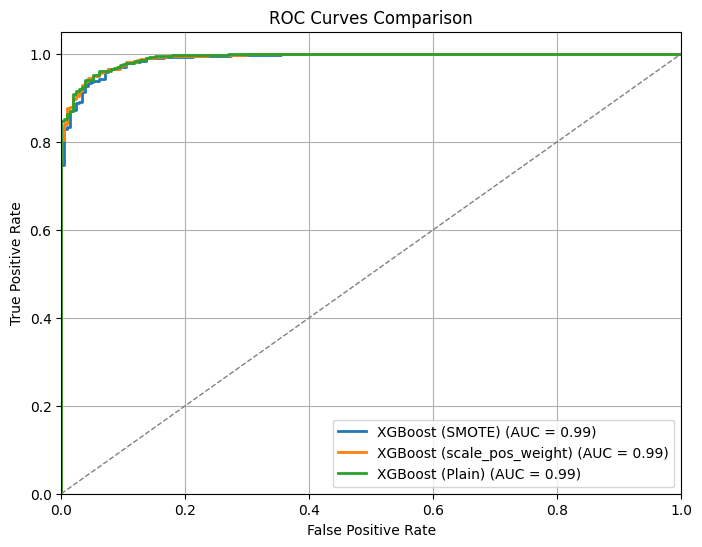

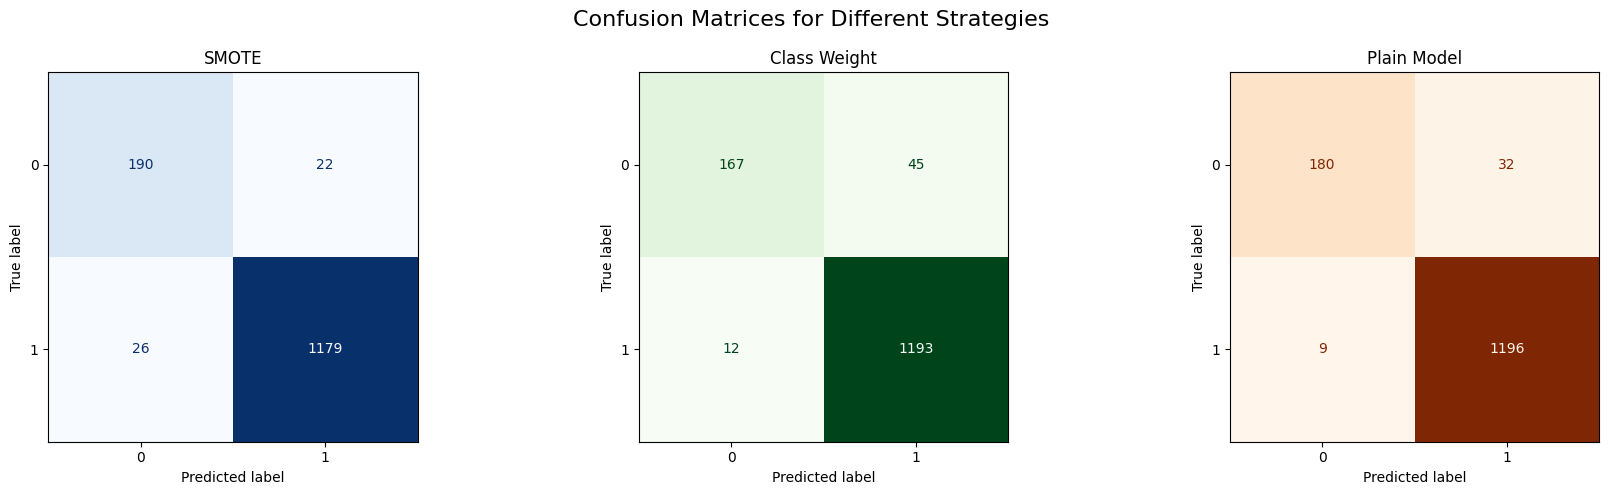

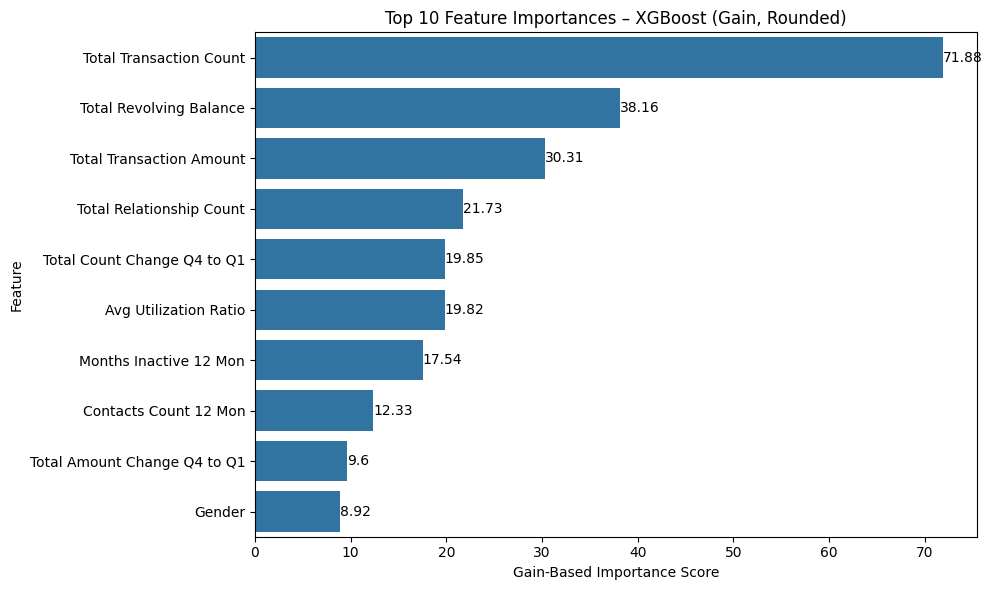

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, roc_curve, auc
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline as SkPipeline
from xgboost import XGBClassifier
from xgboost import plot_importance

# Split features and target
target = 'Attrition Flag'
features = [col for col in df.columns if col != target]

X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to plot ROC curves for multiple models
def plot_roc_curves(models):
    plt.figure(figsize=(8, 6))
    for model, name in models:
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves Comparison')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Parameter grid for XGBoost
param_grid = {
    'model__n_estimators': [100],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.1],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}

# Model 1: With SMOTE
pipe_smote = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(eval_metric='logloss', random_state=42))
])
grid_smote = GridSearchCV(pipe_smote, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_smote.fit(X_train, y_train)

print("-----With SMOTE-----")
print("Best Parameters:", grid_smote.best_params_)
print("Best CV Score:", grid_smote.best_score_)
y_pred_smote = grid_smote.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_smote))

# Model 2: With class_weight (via scale_pos_weight)
# Compute scale_pos_weight
from collections import Counter
counter = Counter(y_train)
scale_pos_weight = counter[0] / counter[1]  # majority / minority

pipe_weight = SkPipeline([
    ('model', XGBClassifier(eval_metric='logloss',
                            random_state=42, scale_pos_weight=scale_pos_weight))
])
grid_weight = GridSearchCV(pipe_weight, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_weight.fit(X_train, y_train)

print("\n-----Without SMOTE,With scale_pos_weight-----")
print("Best Parameters:", grid_weight.best_params_)
print("Best CV Score:", grid_weight.best_score_)
y_pred_weight = grid_weight.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_weight))

# Model 3: Plain XGBoost (no SMOTE, no weighting)
pipe_plain = SkPipeline([
    ('model', XGBClassifier(eval_metric='logloss', random_state=42))
])
grid_plain = GridSearchCV(pipe_plain, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_plain.fit(X_train, y_train)

print("\n-----Without SMOTE and Without scale_pos_weight-----")
print("Best Parameters:", grid_plain.best_params_)
print("Best CV Score:", grid_plain.best_score_)
y_pred_plain = grid_plain.predict(X_test)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_plain))

# Plot ROC curves
plot_roc_curves([
    (grid_smote.best_estimator_, "XGBoost (SMOTE)"),
    (grid_weight.best_estimator_, "XGBoost (scale_pos_weight)"),
    (grid_plain.best_estimator_, "XGBoost (Plain)")
])
# Compute confusion matrices
cm_smote = confusion_matrix(y_test, y_pred_smote)
cm_weight = confusion_matrix(y_test, y_pred_weighted)
cm_plain = confusion_matrix(y_test, y_pred_plain)

# Get labels (assumes binary classification with 0 and 1)
labels = grid_plain.best_estimator_.named_steps['model'].classes_

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot SMOTE confusion matrix
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=labels)
disp1.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('SMOTE')

# Plot class_weight confusion matrix
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_weight, display_labels=labels)
disp2.plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Class Weight')

# Plot plain model confusion matrix
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm_plain, display_labels=labels)
disp3.plot(ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title('Plain Model')

# Layout adjustments
plt.suptitle('Confusion Matrices for Different Strategies', fontsize=16)
plt.tight_layout()
plt.show()

# Get the trained XGBoost model from your pipeline
xgb_model = grid_smote.best_estimator_.named_steps['model']  # or grid_weight, etc.

# Get gain-based importance from booster
booster = xgb_model.get_booster()
score_dict = booster.get_score(importance_type='gain')

# Create DataFrame from importance scores
importance_df = pd.DataFrame.from_dict(score_dict, orient='index', columns=['Importance'])
importance_df.index.name = 'Feature'
importance_df = importance_df.reset_index()

# Round for display
importance_df['Rounded'] = importance_df['Importance'].round(2)

# Sort top N
top_n = 10
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(top_n).reset_index(drop=True)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Importance', y='Feature', data=importance_df)

# Annotate rounded values
for i, row in importance_df.iterrows():
    ax.text(
        row['Importance'] + 0.01, i,
        f"{row['Rounded']}",
        va='center',
        fontsize=10,
        color='black'
    )

plt.title("Top 10 Feature Importances – XGBoost (Gain, Rounded)")
plt.xlabel("Gain-Based Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
#using stratifiedKFold and crossValidate to verify result is not overfitted
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, recall_score, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scaler = StandardScaler()
X_np = X.to_numpy()
y_np = y.to_numpy()

# Scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'f1_macro': 'f1_macro',
    'recall_0': make_scorer(recall_score, pos_label=0),
    'recall_1': make_scorer(recall_score, pos_label=1),
    'f1_0': make_scorer(f1_score, pos_label=0),
    'f1_1': make_scorer(f1_score, pos_label=1)
}

# Evaluation function
def evaluate_pipeline(pipeline, X, y, label):
    results = cross_validate(pipeline, X, y, cv=cv, scoring=scoring, return_train_score=False)
    df = pd.Series({f"test_{k}": round(results[f'test_{k}'].mean(), 6) for k in scoring})
    df.name = label
    return df

# Model 1: Plain XGBoost
pipe_plain_xgb = ImbPipeline([
    ('scaler', scaler),
    ('model', XGBClassifier(eval_metric='logloss', random_state=42))
])

# Model 2: XGBoost with scale_pos_weight
# Use weight = ratio of negative to positive class
pos_weight = (y_np == 0).sum() / (y_np == 1).sum()
pipe_weight_xgb = ImbPipeline([
    ('scaler', scaler),
    ('model', XGBClassifier(scale_pos_weight=pos_weight,
                            eval_metric='logloss', random_state=42))
])

# Model 3: XGBoost with SMOTE
pipe_smote_xgb = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', scaler),
    ('model', XGClassifier( eval_metric='logloss', random_state=42))
])

# Run evaluations
results_plain_xgb = evaluate_pipeline(pipe_plain_xgb, X_np, y_np, "XGB - Plain")
results_weight_xgb = evaluate_pipeline(pipe_weight_xgb, X_np, y_np, "XGB - Weighted")
results_smote_xgb = evaluate_pipeline(pipe_smote_xgb, X_np, y_np, "XGB - SMOTE")

# Combine into table
xgb_results_df = pd.concat([results_plain_xgb, results_weight_xgb, results_smote_xgb], axis=1)
print(xgb_results_df)

               XGB - Plain  XGB - Weighted  XGB - SMOTE
test_accuracy     0.968789        0.965541     0.966812
test_f1_macro     0.939876        0.936334     0.937323
test_recall_0     0.875098        0.916422     0.893952
test_recall_1     0.986260        0.974699     0.980396
test_f1_0         0.898184        0.893213     0.894332
test_f1_1         0.981569        0.979454     0.980313


with smote, XG performs better at recall for class 0 with a 1.9% increase, with a trade of on sligtly worst performance for f1 score on class 0 and recall for class 1 as well as f1 macro, fit time is increase to 1.53 from 99s but should be neglible in the grand scheme.

However, altough it performed well smote is the worst performing out of the 3.

With Weighted having the highest reacall for class 0 for catching churners, the trade off wher class 1 recall is worst is worth it to catch most churners.

for balance, plain works better with highest overall accuracy and f1 marco, less biasy may generalise better.